In [1]:
import sys
import os

sys.path.append(os.path.abspath(".."))

In [2]:
from src.data import create_generators
from src.model import build_model
from src.train import train_model
from src.evaluate import evaluate_model
from src.visualize import show_portfolio
from src.config import *


In [3]:
#Load data

train_gen, val_gen, test_gen = create_generators(
    TRAIN_DIR,
    VAL_DIR,
    TEST_DIR
)

Found 280 images belonging to 4 classes.


Found 60 images belonging to 4 classes.
Found 60 images belonging to 4 classes.


In [4]:
#Build the model

model = build_model(NUM_CLASSES)
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,422,468 (9.24 MB)

 Trainable params: 164,484 (642.52 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [5]:
#Train the model

history = train_model(model, train_gen, val_gen)

Epoch 1/20
 5/18 ━━━━━━━━━━━━━━━━━━━━ 4s 352ms/step - accuracy: 0.3119 - loss: 1.6916

f:\Documentos\Ejercicios DS para laburar\Image Classification Electrical grid\venv\lib\site-packages\PIL\Image.py:1034: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


18/18 ━━━━━━━━━━━━━━━━━━━━ 15s 515ms/step - accuracy: 0.3750 - loss: 1.4240 - val_accuracy: 0.6000 - val_loss: 0.9531
Epoch 2/20
18/18 ━━━━━━━━━━━━━━━━━━━━ 4s 220ms/step - accuracy: 0.6464 - loss: 0.9263 - val_accuracy: 0.6833 - val_loss: 0.7907
Epoch 3/20
18/18 ━━━━━━━━━━━━━━━━━━━━ 4s 216ms/step - accuracy: 0.6607 - loss: 0.8662 - val_accuracy: 0.7833 - val_loss: 0.6736
Epoch 4/20
18/18 ━━━━━━━━━━━━━━━━━━━━ 4s 216ms/step - accuracy: 0.7107 - loss: 0.7292 - val_accuracy: 0.8333 - val_loss: 0.5875
Epoch 5/20
18/18 ━━━━━━━━━━━━━━━━━━━━ 4s 217ms/step - accuracy: 0.7893 - loss: 0.6304 - val_accuracy: 0.8500 - val_loss: 0.5312
Epoch 6/20
18/18 ━━━━━━━━━━━━━━━━━━━━ 4s 215ms/step - accuracy: 0.8286 - loss: 0.5659 - val_accuracy: 0.8667 - val_loss: 0.4713
Epoch 7/20
18/18 ━━━━━━━━━━━━━━━━━━━━ 4s 216ms/step - accuracy: 0.8107 - loss: 0.5427 - val_accuracy: 0.9167 - val_loss: 0.4176
Epoch 8/20
18/18 ━━━━━━━━━━━━━━━━━━━━ 4s 233ms/step - accuracy: 0.8607 - loss: 0.4137 - val_accuracy: 0.9167 - val

In [6]:
#Evaluate the model

evaluate_model(model, test_gen)

Starting evaluation...
4/4 ━━━━━━━━━━━━━━━━━━━━ 2s 435ms/step

Classification Report:

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        15
           1       0.68      0.87      0.76        15
           2       0.93      0.93      0.93        15
           3       0.82      0.60      0.69        15

    accuracy                           0.85        60
   macro avg       0.86      0.85      0.85        60
weighted avg       0.86      0.85      0.85        60


Results saved to: models/results_20260302_174314.json
Confusion matrix saved to: models/confusion_matrix_20260302_174314.png


(0.85,
 {'0': {'precision': 1.0, 'recall': 1.0, 'f1-score': 1.0, 'support': 15.0},
  '1': {'precision': 0.6842105263157895,
   'recall': 0.8666666666666667,
   'f1-score': 0.7647058823529411,
   'support': 15.0},
  '2': {'precision': 0.9333333333333333,
   'recall': 0.9333333333333333,
   'f1-score': 0.9333333333333333,
   'support': 15.0},
  '3': {'precision': 0.8181818181818182,
   'recall': 0.6,
   'f1-score': 0.6923076923076923,
   'support': 15.0},
  'accuracy': 0.85,
  'macro avg': {'precision': 0.8589314194577353,
   'recall': 0.85,
   'f1-score': 0.8475867269984918,
   'support': 60.0},
  'weighted avg': {'precision': 0.8589314194577352,
   'recall': 0.85,
   'f1-score': 0.8475867269984917,
   'support': 60.0}},
 array([[15,  0,  0,  0],
        [ 0, 13,  0,  2],
        [ 0,  1, 14,  0],
        [ 0,  5,  1,  9]]))

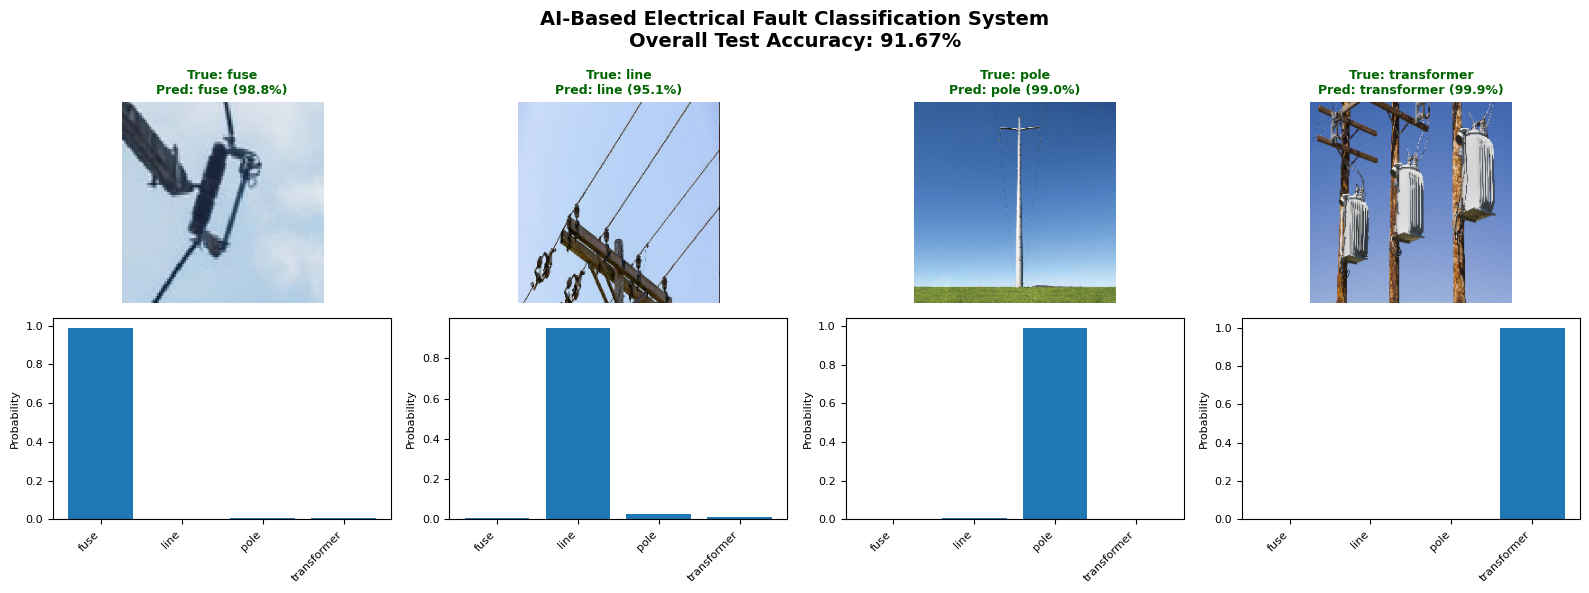

Professional IEEE-style figure saved as: Sample per class.png


In [7]:

show_portfolio(model, test_gen)